In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(1,'/Users/sadmin/Documents/MeerFish') # path to MeerFish code
import cosmo
import survey
import model
import fisher

f_tobsloss = 0.5 # fraction of observation time loss (XLP assumed 0.5)
N_dish = 60 # number of operational dishes out of full 64 in array (XLP assumed 60)

## parameters to include in Fisher forecast:
theta_ids = [\
    r'$\mathcal{A}_1$',\
    #r'$b_1$',\
    #r'$b_2$',\
    #r'$b^\phi_1$',\
    #r'$b^\phi_2$',\
    #r'$f$',\
    #r'$\alpha_\perp$',\
    #r'$\alpha_\parallel$',\
    #r'$A_{\rm BAO}$',\
    #r'$f_{\rm NL}$'\
    r'$\beta_1$',\
    r'$\beta_2$',\
    ]

Survey1_arg = 'MK_UHF' # MeerKLASS UHF-band IM survey
Survey2_arg = 'DESI_LRG' # DESI LRG galaxies
t_obs = 800 * (1-f_tobsloss) # total MeerKLASS observation time (with losses then applied)
A_sky = 4000 # original sky area
A_skyX = 3000 # sky area overlapping with DESI galaxies

ZesVersion = True # use Ze's (XLP) models for HI bias and \bar{T}_HI

kmax = 0.1/0.7 # [h/Mpc] matching Ze's (XLP) cut - beyond this non-linear/gridding and instrumental effects dominate

### Choose which power spectrum multipoles:
ells = [0,2,4] # first three non-zero multipoles

### Demo RSD effect on multipoles:

The cross-correlation power spectrum model can be expressed as

$$P_{\rm HI,g}(k,\mu)
= \bar{T}_{\rm HI}\, b_{\rm HI}\, b_g
\left(1 + \beta_{\rm HI}\,\mu^2 \right)
\left(1 + \beta_g\,\mu^2 \right)
P_m(k)\, D_{\rm FoG}(k,\mu)$$

where $\beta_{\rm HI} = f/b_{\rm HI}$, and $\beta_g = f/b_{\rm g}$. 

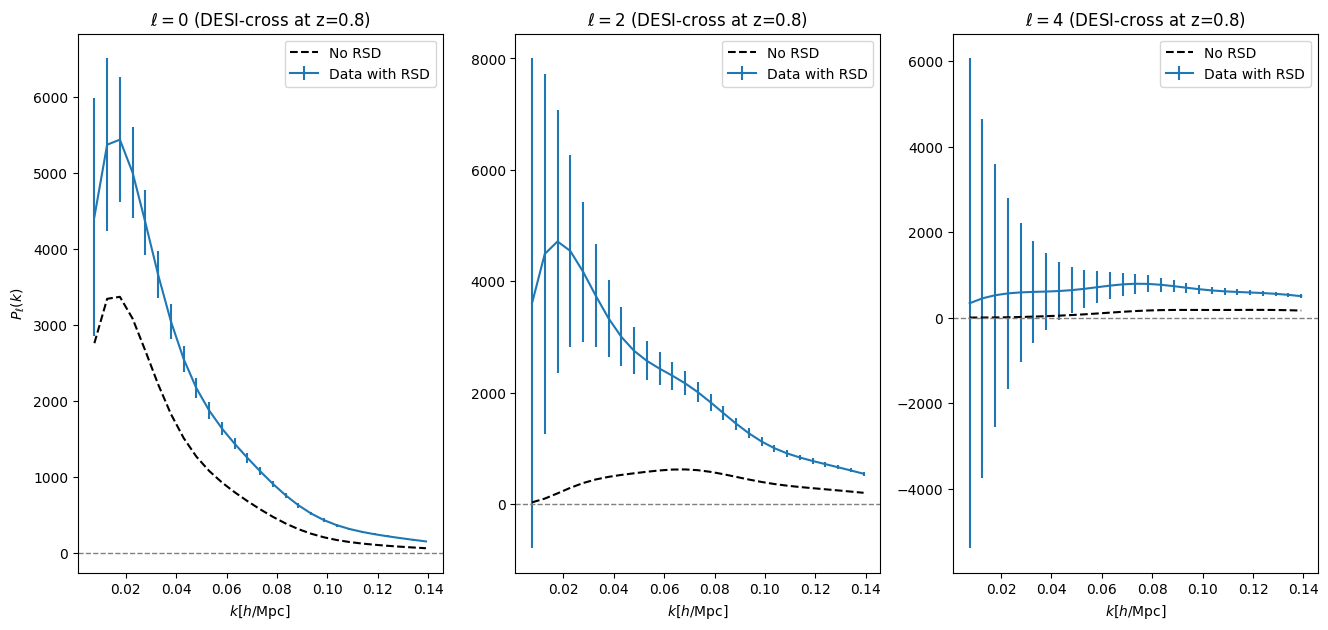

In [2]:
z = 0.8
deltaz = 0.2 # redshift width for each bin
zminzmax = [z-deltaz/2,z+deltaz/2] # use default

z,zmin1,zmin2,zmax1,zmax2,A_sky1,A_sky2,V_bin1,V_bin2,V_binX,theta_FWHM1,theta_FWHM2,t_tot,N_dish,sigma_z1,sigma_z2,P_N,nbar = survey.params(Survey1=Survey1_arg,Survey2=Survey2_arg,zminzmax=zminzmax,A_sky1=A_sky,t_tot=t_obs,N_dish=N_dish,T_sys=model.Tsys(np.mean(zminzmax)))
k_fg = 0 # explore this later
dpix,dnu = 0.5,0.133 # MeerKLASS UHF maps
dpix,dnu = None,None
surveypars = z,V_bin1,V_bin2,V_binX,theta_FWHM1,theta_FWHM2,sigma_z1,sigma_z2,P_N,1/nbar,k_fg,dpix,dnu
cosmopars = cosmo.SetCosmology(z=z,return_cosmopars=True,ZesVersion=ZesVersion,beta_par=True) # set initial default cosmology
amp1,amp2,b1,b2,bphi1,bphi2,f,a_perp,a_para,A_BAO,f_NL,beta1,beta2 = cosmopars
nuispars = 0,0,0 # ignore nuisance parameters throughout
Pmod = cosmo.MatterPk(z)
k,kbins,kmin,kmax = model.get_kbins(z,zminzmax[0],zminzmax[1],A_sky=A_skyX,kmax=kmax,Taruya=True)

### Compare non-RSD with RSD mutlipoles:
cosmopars_noRSD = np.array([amp1,amp2,b1,b2,bphi1,bphi2,f,a_perp,a_para,A_BAO,f_NL,0,0]) # set beta's to zero
plt.figure(figsize=(16,7))
for i in range(3):
    P_X = model.P_ell(ells[i],k,Pmod,cosmopars,surveypars,nuispars,'X')
    P_err = model.sigma_ell_error(ells[i],k,Pmod,cosmopars,surveypars,nuispars,'X')
    plt.subplot(131+i)
    plt.errorbar(k,P_X,P_err,label='Data with RSD')

    P_X = model.P_ell(ells[i],k,Pmod,cosmopars_noRSD,surveypars,nuispars,'X')
    plt.plot(k,P_X,ls='--',color='black',label='No RSD')

    plt.axhline(1,color='gray',ls='--',lw=1)
    plt.xlabel(r'$k [h/{\rm Mpc}]$')
    if i==0: plt.ylabel(r'$P_\ell(k)$')
    plt.title(r'$\ell=%s$ (DESI-cross at z=%s)'%(ells[i],z)) 
    plt.legend()
plt.show()

### Run forecast on RSD detection:
To detect RSD robustly we want to include degeneracy with the scale-independent amplitude parameters such as the biases and the HI temperature. We treat these as a grouped nuisance parameter given by $\mathcal{A}_{\rm HI,g} = \bar{T}_{\rm HI}b_{\rm HI}b_{\rm g}$. The model becomes (we ignore fingers-of-god here as they should be sub-dominant)

$$P_{\rm HI,g}(k,\mu)
= \mathcal{A}_{\rm HI,g}
\left(1 + \beta_{\rm HI}\,\mu^2 \right)
\left(1 + \beta_g\,\mu^2 \right)
P_m(k)$$

We can now do a $\Delta\chi^2$ test between this model and a null-RSD model, in both cases fitting for the degenerate parameter $\mathcal{A}_{\rm HI,g}$. For the null-RSD model we simply set both $\beta_{\rm HI} = \beta_{\rm g} = 0$.

Given a measurement of the multipole $P_\ell(k)$ with uncertainty $\sigma_\ell(k)$, we define

$$
\chi^2 =
\sum_{\ell,k}
\frac{\left[P_\ell^{\rm data}(k) - P_\ell^{\rm model}(k;\,\mathcal{A}_{\rm HI,g})\right]^2}
{\sigma_\ell(k)^2}
$$

where $P_\ell^{\rm model}(k;\mathcal{A}_{\rm HI,g})$ depends on the amplitude parameter $\mathcal{A}_{\rm HI,g}$. For each model (RSD and no-RSD), we minimise with respect to this parameter:

$$
\chi^2_{\rm model} = \min_{\mathcal{A}_{\rm HI,g}} \chi^2
$$

### RSD detection significance

We then compare the best-fit $\chi^2$ values for the RSD and no-RSD models:

$$
\Delta \chi^2 =
\chi^2_{\rm no\,RSD} - \chi^2_{\rm RSD}
$$

The significance of the RSD detection is given by

$$
\mathrm{SNR} = \sqrt{\Delta \chi^2}
$$


RSD detection in cross-correlation power: 10.263504730985003 sigma
RSD detection in HI-gas: 5.34202509579952 sigma


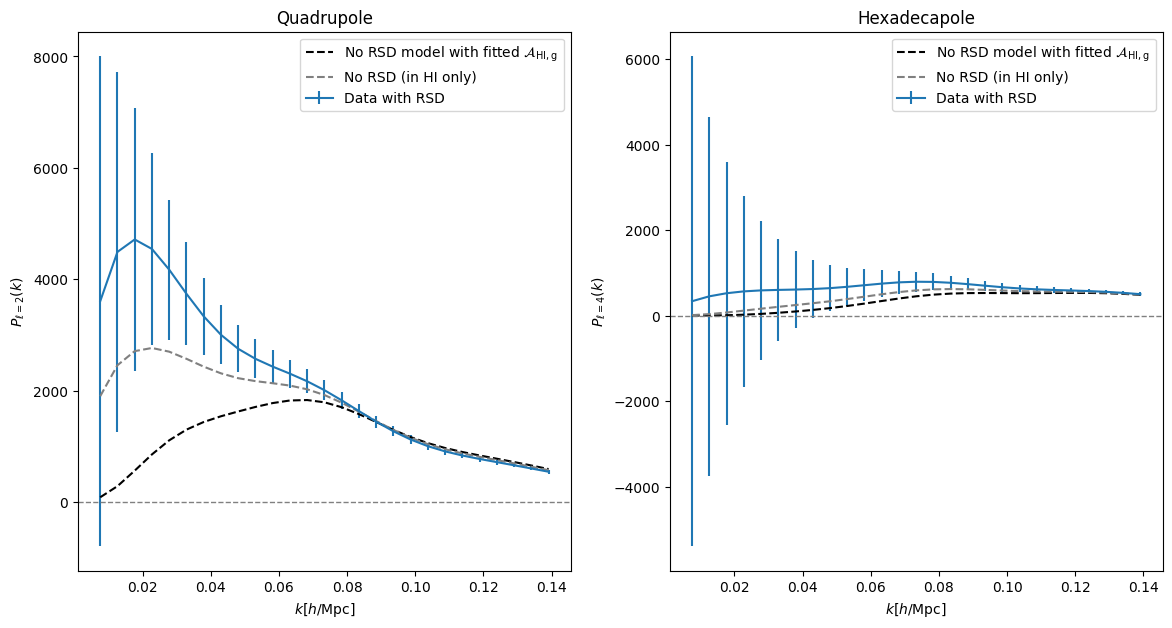

In [3]:
import scipy

ells = [2,4]
P_data,P_err = [],[]
for ell_i in ells:        
    P_data.append( model.P_ell(ell_i,k,Pmod,cosmopars,surveypars,nuispars,'X') ) # treat data as pure wRSD model
    P_err.append( model.sigma_ell_error(ell_i,k,Pmod,cosmopars,surveypars,nuispars,'X') )
P_data,P_err = np.concatenate(P_data),np.concatenate(P_err)

def chi2_wRSD_func(params,P_data,P_err,tracer,ells):
    amp1_trial = params[0]
    cosmopars = np.array([amp1_trial,amp2,b1,b2,bphi1,bphi2,f,a_perp,a_para,A_BAO,f_NL,beta1,beta2])
    P_wRSD = []
    for ell_i in ells:        
        P_wRSD.append( model.P_ell(ell_i,k,Pmod,cosmopars,surveypars,nuispars,tracer) ) # with RSD model with varying amplitude
    P_wRSD = np.concatenate(P_wRSD)
    return np.sum((P_data - P_wRSD)**2 / P_err**2)

def chi2_noRSD_func(params,P_data,P_err,tracer,ells):
    amp1_trial = params[0]
    cosmopars_noRSD = np.array([amp1_trial,amp2,b1,b2,bphi1,bphi2,f,a_perp,a_para,A_BAO,f_NL,0,0]) # set beta's to zero
    P_noRSD = []
    for ell_i in ells:        
        P_noRSD.append( model.P_ell(ell_i,k,Pmod,cosmopars_noRSD,surveypars,nuispars,tracer) ) # no RSD model with varying amplitude
    P_noRSD = np.concatenate(P_noRSD)
    return np.sum((P_data - P_noRSD)**2 / P_err**2)

def chi2_noHIRSD_func(params,P_data,P_err,tracer,ells):
    '''Same as above, but null model is with RSD switched off only for HI tracer for direct RSD in HI detection test'''
    amp1_trial = params[0]
    cosmopars_noRSD = np.array([amp1_trial,amp2,b1,b2,bphi1,bphi2,f,a_perp,a_para,A_BAO,f_NL,0, beta2]) # set beta's to zero
    P_noRSD = []
    for ell_i in ells:        
        P_noRSD.append( model.P_ell(ell_i,k,Pmod,cosmopars_noRSD,surveypars,nuispars,tracer) ) # no RSD model with varying amplitude
    P_noRSD = np.concatenate(P_noRSD)
    return np.sum((P_data - P_noRSD)**2 / P_err**2)

res = scipy.optimize.minimize(chi2_wRSD_func,x0=[amp1],args=(P_data,P_err,'X',ells))
chi2_wRSD = res.fun
res = scipy.optimize.minimize(chi2_noRSD_func,x0=[amp1],args=(P_data,P_err,'X',ells))
chi2_noRSD = res.fun
snr = np.sqrt(chi2_noRSD - chi2_wRSD)
print("RSD detection in cross-correlation power:",snr,"sigma")

### Check found best-fit amplitude:
A_best = res.x[0]
cosmopars_noRSD = np.array([A_best,amp2,b1,b2,bphi1,bphi2,f,a_perp,a_para,A_BAO,f_NL,0,0]) # set beta's to zero
plt.figure(figsize=(14,7))
for i,ell_i in enumerate(ells):
    #plt.subplot(121+i)
    plt.subplot(1, len(ells), i+1)
    P_X = model.P_ell(ell_i,k,Pmod,cosmopars,surveypars,nuispars,'X')
    P_err_ell = model.sigma_ell_error(ell_i,k,Pmod,cosmopars,surveypars,nuispars,'X')
    plt.errorbar(k,P_X,P_err_ell,label='Data with RSD')
    P_X = model.P_ell(ell_i,k,Pmod,cosmopars_noRSD,surveypars,nuispars,'X')
    plt.plot(k,P_X,ls='--',color='black',label=r'No RSD model with fitted $\mathcal{A}_{\rm HI,g}$')
    plt.axhline(1,color='gray',ls='--',lw=1)
    plt.xlabel(r'$k [h/{\rm Mpc}]$')
    plt.ylabel(r'$P_{\ell=%s}(k)$'%ell_i)
    if ell_i==2: plt.title('Quadrupole')
    if ell_i==4: plt.title('Hexadecapole')
        
res = scipy.optimize.minimize(chi2_wRSD_func,x0=[amp1],args=(P_data,P_err,'X',ells))
chi2_wRSD = res.fun
res = scipy.optimize.minimize(chi2_noHIRSD_func,x0=[amp1],args=(P_data,P_err,'X',ells))
chi2_noRSD = res.fun
snr = np.sqrt(chi2_noRSD - chi2_wRSD)
print("RSD detection in HI-gas:",snr,"sigma")

### Check found best-fit amplitude for HI-only no RSD:
A_best = res.x[0]
cosmopars_noRSD = np.array([A_best,amp2,b1,b2,bphi1,bphi2,f,a_perp,a_para,A_BAO,f_NL,0,beta2]) # set beta's to zero
for i,ell_i in enumerate(ells):
    plt.subplot(1, len(ells), i+1)
    P_X = model.P_ell(ell_i,k,Pmod,cosmopars_noRSD,surveypars,nuispars,'X')
    plt.plot(k,P_X,ls='--',color='gray',label=r'No RSD (in HI only)')
    plt.legend()
plt.show()

### Reproduce Table 1 from XLP submission but for RSD detection:
Just consider the RSD from the quadrupole

In [4]:
years = ["2023–2024*", "2024–2025", "2025–2026", "2026–2027", "2027–2028"]
t_add = [380,500,500,550,570]
t_obss = np.cumsum(t_add) # cumulative observing time
A_skys = [1600,3600,5600,7800,10000]
zs = [0.43,0.61,0.8,1]
deltazs = [0.06,0.18,0.2,0.2,0.2]

ells = [2,4]

RSD_SNR,RSD_SNR_x = np.zeros((len(t_add),len(zs))),np.zeros((len(t_add),len(zs)))
for i in range(len(t_add)):
    for j in range(len(zs)):
        sys.stdout.write(f"\r{i}, {j}")
        sys.stdout.flush()
                
        A_skyX = A_skys[i] * 3/4
        if A_skyX>3000: A_skyX = 3000
        if zs[j]<=0.8: Survey2_arg_j = 'DESI_LRG' # DESI LRG galaxies
        if zs[j]>0.8: Survey2_arg_j = 'DESI_ELG' # DESI ELG galaxies

        t_obs_i = t_obss[i] * (1-f_tobsloss) # apply observation time losses
        
        zminzmax = [zs[j]-deltazs[j]/2,zs[j]+deltazs[j]/2] # use default
        z,zmin1,zmin2,zmax1,zmax2,A_sky1,A_sky2,V_bin1,V_bin2,V_binX,theta_FWHM1,theta_FWHM2,t_tot,N_dish,sigma_z1,sigma_z2,P_N,nbar = survey.params(Survey1=Survey1_arg,Survey2=Survey2_arg_j,zminzmax=zminzmax,A_sky1=A_skys[i],A_skyX=A_skyX,t_tot=t_obs_i,N_dish=N_dish,T_sys=model.Tsys(np.mean(zminzmax)))
        surveypars = z,V_bin1,V_bin2,V_binX,theta_FWHM1,theta_FWHM2,sigma_z1,sigma_z2,P_N,1/nbar,k_fg,dpix,dnu
        cosmopars = cosmo.SetCosmology(z=z,return_cosmopars=True,ZesVersion=ZesVersion) # set initial default cosmology
        amp1,amp2,b1,b2,bphi1,bphi2,f,a_perp,a_para,A_BAO,f_NL,beta1,beta2 = cosmopars
        Pmod = cosmo.MatterPk(z)
    
        ### HI auto:
        k,kbins,kmin,kmax = model.get_kbins(z,zminzmax[0],zminzmax[1],A_sky=A_sky1,kmax=kmax,Taruya=True)
        P_data,P_err = [],[]
        for ell_i in ells:        
            P_data.append( model.P_ell(ell_i,k,Pmod,cosmopars,surveypars,nuispars,'1') ) # treat data as pure wRSD model
            P_err.append( model.sigma_ell_error(ell_i,k,Pmod,cosmopars,surveypars,nuispars,'1') )
        P_data,P_err = np.concatenate(P_data),np.concatenate(P_err)        
        res = scipy.optimize.minimize(chi2_wRSD_func,x0=[amp1],args=(P_data,P_err,'1',ells))
        chi2_wRSD = res.fun
        res = scipy.optimize.minimize(chi2_noRSD_func,x0=[amp1],args=(P_data,P_err,'1',ells))
        chi2_noRSD = res.fun
        RSD_SNR[i,j] = np.sqrt(chi2_noRSD - chi2_wRSD)

        ### Cross-correlation:
        k,kbins,kmin,kmax = model.get_kbins(z,zminzmax[0],zminzmax[1],A_sky=A_skyX,kmax=kmax,Taruya=True)
        P_data,P_err = [],[]
        for ell_i in ells:        
            P_data.append( model.P_ell(ell_i,k,Pmod,cosmopars,surveypars,nuispars,'X') ) # treat data as pure wRSD model
            P_err.append( model.sigma_ell_error(ell_i,k,Pmod,cosmopars,surveypars,nuispars,'X') )
        P_data,P_err = np.concatenate(P_data),np.concatenate(P_err)
        res = scipy.optimize.minimize(chi2_wRSD_func,x0=[amp1],args=(P_data,P_err,'X',ells))
        chi2_wRSD = res.fun
        res = scipy.optimize.minimize(chi2_noRSD_func,x0=[amp1],args=(P_data,P_err,'X',ells))
        chi2_noRSD = res.fun
        RSD_SNR_x[i,j] = np.sqrt(chi2_noRSD - chi2_wRSD)

from IPython.display import Markdown, display
RSD_combined = np.sqrt(np.sum(RSD_SNR**2, axis=1)) # Combined in quadrature (typical for SNR)
RSD_combined_x = np.sqrt(np.sum(RSD_SNR_x**2, axis=1)) # Combined in quadrature (typical for SNR)

###########################################################################################
### Below is code only for generating table in notebook: 
###########################################################################################
### Auto-correlation:
display(Markdown(f"## Auto-correlation $\ell={ells}$:"))
table = f"""
| Year | Obs. time [h] | Total area [deg$^2$] | RSD SNR z={zs[0]} | z={zs[1]} | z={zs[2]} | z={zs[3]} | Combined |
|:----:|:-------------:|:--------------------:|:----------------:|:--------:|:--------:|:--------:|:--------:|
"""
for i in range(len(years)):
    if i == 0: # Format obs time (first entry no "+")
        t_str = f"{t_add[i]}"
    else:
        t_str = f"+{t_add[i]}"
    table += (
        f"| {years[i]} | {t_str} | {A_skys[i]} | "
        f"{RSD_SNR[i,0]:.1f} | {RSD_SNR[i,1]:.1f} | "
        f"{RSD_SNR[i,2]:.1f} | {RSD_SNR[i,3]:.1f} | "
        f"{RSD_combined[i]:.1f} |\n"
    )
display(Markdown(table))

### Cross-correlation:
display(Markdown(f"## Cross-correlation $\ell={ells}$ (with DESI):"))
display(Markdown(f"Assumes maximum 75% of MeerKLASS area overlaps with DESI footprint, up to a maximum of 3,000deg$^2$ overlap. Hence diminishing increases are reached once all possible overlap has been observed."))
table = f"""
| Year | Obs. time [h] | Total area [deg$^2$] | RSD SNR z={zs[0]} | z={zs[1]} | z={zs[2]} | z={zs[3]} | Combined |
|:----:|:-------------:|:--------------------:|:----------------:|:--------:|:--------:|:--------:|:--------:|
"""
for i in range(len(years)):
    if i == 0: # Format obs time (first entry no "+")
        t_str = f"{t_add[i]}"
    else:
        t_str = f"+{t_add[i]}"
    table += (
        f"| {years[i]} | {t_str} | {A_skys[i]} | "
        f"{RSD_SNR_x[i,0]:.1f} | {RSD_SNR_x[i,1]:.1f} | "
        f"{RSD_SNR_x[i,2]:.1f} | {RSD_SNR_x[i,3]:.1f} | "
        f"{RSD_combined_x[i]:.1f} |\n"
    )
display(Markdown(table))

4, 3

## Auto-correlation $\ell=[2, 4]$:


| Year | Obs. time [h] | Total area [deg$^2$] | RSD SNR z=0.43 | z=0.61 | z=0.8 | z=1 | Combined |
|:----:|:-------------:|:--------------------:|:----------------:|:--------:|:--------:|:--------:|:--------:|
| 2023–2024* | 380 | 1600 | 3.7 | 5.8 | 4.6 | 3.4 | 8.9 |
| 2024–2025 | +500 | 3600 | 5.7 | 8.9 | 6.9 | 5.1 | 13.6 |
| 2025–2026 | +500 | 5600 | 7.0 | 11.1 | 8.7 | 6.3 | 16.9 |
| 2026–2027 | +550 | 7800 | 8.2 | 13.0 | 10.2 | 7.5 | 19.9 |
| 2027–2028 | +570 | 10000 | 9.5 | 14.8 | 11.6 | 8.5 | 22.7 |


## Cross-correlation $\ell=[2, 4]$ (with DESI):

Assumes maximum 75% of MeerKLASS area overlaps with DESI footprint, up to a maximum of 3,000deg$^2$ overlap. Hence diminishing increases are reached once all possible overlap has been observed.


| Year | Obs. time [h] | Total area [deg$^2$] | RSD SNR z=0.43 | z=0.61 | z=0.8 | z=1 | Combined |
|:----:|:-------------:|:--------------------:|:----------------:|:--------:|:--------:|:--------:|:--------:|
| 2023–2024* | 380 | 1600 | 3.2 | 6.3 | 5.6 | 4.3 | 10.0 |
| 2024–2025 | +500 | 3600 | 4.7 | 9.3 | 8.5 | 6.4 | 14.9 |
| 2025–2026 | +500 | 5600 | 5.2 | 9.9 | 9.0 | 6.8 | 15.8 |
| 2026–2027 | +550 | 7800 | 5.2 | 9.9 | 9.0 | 6.8 | 15.8 |
| 2027–2028 | +570 | 10000 | 5.2 | 9.9 | 9.0 | 6.8 | 15.8 |
